# HYDRA saliency walkthrough on Coffee

This notebook provides a compact, reproducible walkthrough of the saliency workflow used in the accompanying HYDRA reproduction study.  It focuses on the UCR **Coffee** dataset so that the full sequence of steps can be inspected interactively without running the complete 128-dataset benchmark.

The notebook demonstrates:

- loading a UCR train/test split;
- fitting the explainable HYDRA wrapper;
- projecting HYDRA classifier evidence back to the temporal domain;
- evaluating saliency with top, random and bottom masking;
- fitting MrSQM as an interpretability-oriented comparator; and
- visualising both saliency profiles and simple signal-morphology windows.

The full paper results should be regenerated with the script-based pipeline described in `README.md`; this notebook is intended as an academic walkthrough and sanity check.


## Setup

The import block is written to work when the notebook is launched from the repository root, or from a notebook subdirectory inside the repository.  Outputs are written to local `outputs/coffee_walkthrough/` and `figures/coffee_walkthrough/` folders so that they do not overwrite the main paper outputs.


In [ ]:
from __future__ import annotations

import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root(start: Path | None = None) -> Path:
    '''Return the repository root containing main.py, classes/ and utils/
    '''
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "main.py").exists() and (candidate / "classes").exists() and (candidate / "utils").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the HYDRA repository root. Run this notebook from inside the cloned repository."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.data_utils import load_dataset
from utils.explainability import evaluate_masking_dataset
from classes.models.hydra_explainable import HydraModelExplainable
from classes.models.mrsqm_explainable import MrSQMExplainableModel

DATASET = "Coffee"
FRACTIONS = (0.05, 0.10, 0.20)
RANDOM_REPEATS = 3
SEED = 42

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "coffee_walkthrough"
FIG_DIR = PROJECT_ROOT / "figures" / "coffee_walkthrough"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

MODE_ORDER = ["top", "random", "bottom"]
MODE_LABELS = {
    "top": "Top-saliency masking",
    "random": "Random masking",
    "bottom": "Bottom-saliency masking",
}
MODE_COLOURS = {
    "top": "#1f77b4",
    "random": "#7f7f7f",
    "bottom": "#d62728",
}

print(f"Project root : {PROJECT_ROOT}")
print(f"Dataset : {DATASET}")
print(f"Device : {DEVICE}")
print(f"Outputs : {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures : {FIG_DIR.relative_to(PROJECT_ROOT)}")


## Load the Coffee dataset

Coffee is a small univariate UCR dataset, which makes it useful for a quick qualitative walkthrough.  We first inspect the split dimensions and plot a few training examples.


Train shape: (28, 286)
Test shape : (28, 286)
Classes    : [0 1]
Metadata   : LabelEncoder()


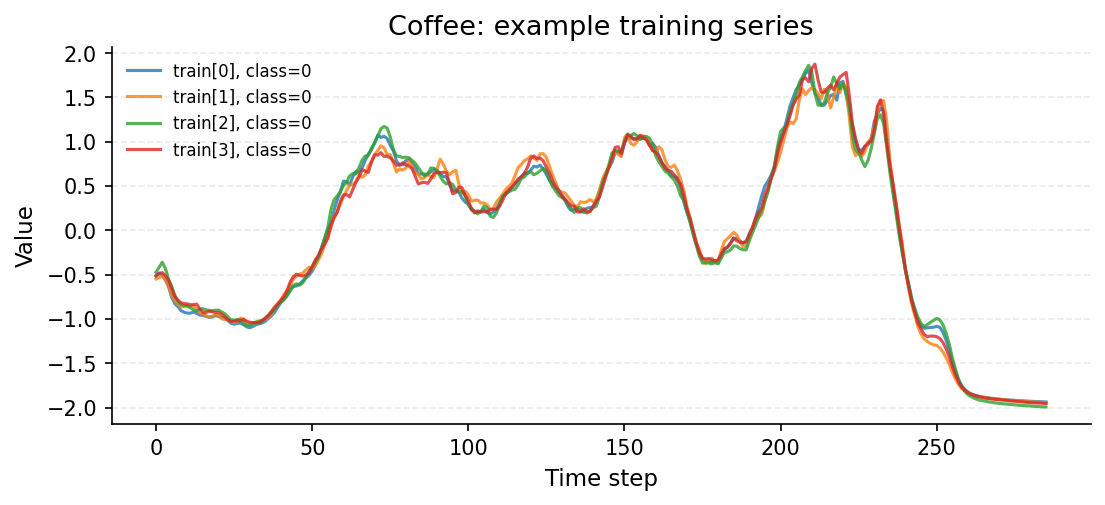

In [ ]:
x_train, y_train, x_test, y_test, metadata = load_dataset(DATASET)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Classes :", np.unique(y_train))
print("Metadata :", metadata)

fig, ax = plt.subplots(figsize=(7.5, 3.5))
for i in range(min(4, len(x_train))):
    series = np.asarray(x_train[i]).squeeze()
    ax.plot(series, alpha=0.8, label=f"train[{i}], class={y_train[i]}")

ax.set_title("Coffee: example training series")
ax.set_xlabel("Time step")
ax.set_ylabel("Value")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, axis="y", linestyle="--", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "coffee_training_examples.png", bbox_inches="tight")
plt.show()


## Helper functions

In [ ]:
def style_axis(ax: plt.Axes) -> None:
    ''' Apply a light horizontal grid used consistently across plots
    '''
    ax.grid(True, axis="y", linestyle="--", alpha=0.30)
    ax.set_axisbelow(True)


def save_figure(fig: plt.Figure, name: str | None) -> None:
    ''' Save a figure as both PNG and PDF when a filename stem is provided
    '''
    if name is None:
        return
    stem = Path(name).with_suffix("").name
    fig.savefig(FIG_DIR / f"{stem}.png", bbox_inches="tight")
    fig.savefig(FIG_DIR / f"{stem}.pdf", bbox_inches="tight")


def as_1d(series: np.ndarray) -> np.ndarray:
    ''' Return a univariate series as a one-dimensional NumPy array
    '''
    return np.asarray(series, dtype=float).squeeze()


def clean_saliency(saliency: np.ndarray) -> np.ndarray:
    ''' Convert saliency to finite absolute values for window selection and plotting
    '''
    saliency = np.asarray(saliency, dtype=float).squeeze()
    saliency = np.nan_to_num(saliency, nan=0.0, posinf=0.0, neginf=0.0)
    return np.abs(saliency)


def normalise_0_100(values: np.ndarray) -> np.ndarray:
    ''' Scale a vector to [0, 100] for visual comparison
    '''
    values = clean_saliency(values)
    vmin, vmax = float(np.min(values)), float(np.max(values))
    if np.isclose(vmin, vmax):
        return np.zeros_like(values)
    return 100.0 * (values - vmin) / (vmax - vmin)


def summarise_masking_metrics(samples_df: pd.DataFrame) -> pd.DataFrame:
    ''' Aggregate perturbation samples by masking fraction and masking mode
    '''
    df = samples_df.copy()
    denom = df["score_before"].abs() + 1e-12
    df["relative_score_drop"] = df["score_drop"] / denom
    df["relative_score_drop_pct"] = 100.0 * df["relative_score_drop"]
    df["bounded_relative_score_drop"] = df["relative_score_drop"].clip(-1.0, 1.0)

    summary = (
        df.groupby(["fraction", "mode"], as_index=False)
        .agg(
            mean_relative_score_drop_pct=("relative_score_drop_pct", "mean"),
            median_relative_score_drop_pct=("relative_score_drop_pct", "median"),
            mean_bounded_relative_score_drop=("bounded_relative_score_drop", "mean"),
            flip_rate=("flipped", "mean"),
            flip_rate_pct=("flipped", lambda x: 100.0 * np.mean(x)),
            n_samples=("flipped", "size"),
        )
        .sort_values(["fraction", "mode"])
    )
    return summary


def choose_shared_correct_example(model_a, model_b, X_test: np.ndarray, y_test: np.ndarray) -> int:
    ''' Select the first test case correctly classified by both models
    '''
    pred_a = model_a.predict(X_test)
    pred_b = model_b.predict(X_test)
    indices = np.where((pred_a == y_test) & (pred_b == y_test))[0]
    if len(indices) == 0:
        raise ValueError("No shared correctly classified test case was found.")
    return int(indices[0])


def plot_signal_with_saliency(series: np.ndarray, saliency: np.ndarray, title: str, save_name: str | None = None) -> None:
    ''' Plot a univariate time series with point colour indicating normalised saliency
    '''
    y = as_1d(series)
    x = np.arange(len(y))
    s = normalise_0_100(saliency)

    fig = plt.figure(figsize=(8.2, 3.8), constrained_layout=True)
    gs = fig.add_gridspec(1, 2, width_ratios=[30, 1])
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])

    scatter = ax.scatter(x, y, c=s, cmap="viridis", s=24, linewidths=0, vmin=0, vmax=100)
    ax.plot(x, y, linewidth=1.1, alpha=0.35, color="black")
    ax.set_title(title)
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")
    style_axis(ax)

    cbar = fig.colorbar(scatter, cax=cax)
    cbar.set_label("Normalised saliency")

    save_figure(fig, save_name)
    plt.show()


def plot_grouped_bars(
    df: pd.DataFrame,
    value_col: str,
    title: str,
    ylabel: str,
    filename: str,
    show_percent_symbol: bool = False,
) -> None:
    '''Plot grouped masking results across masking fractions'''
    fractions = sorted(df["fraction"].unique())
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    x = np.arange(len(fractions))
    width = 0.24
    offsets = [-width, 0, width]

    for offset, mode in zip(offsets, MODE_ORDER):
        sub = df[df["mode"] == mode].sort_values("fraction")
        y = sub[value_col].to_numpy()
        bars = ax.bar(
            x + offset,
            y,
            width=width,
            color=MODE_COLOURS[mode],
            alpha=0.85,
            label=MODE_LABELS[mode],
        )
        for bar, val in zip(bars, y):
            label = f"{val:.1f}%" if show_percent_symbol else f"{val:.2f}"
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                label,
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_title(title)
    ax.set_xlabel("Masked fraction of time steps")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{f:.0%}" for f in fractions])
    style_axis(ax)
    ax.legend(frameon=False, loc="best")
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.15)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


## Fit the explainable HYDRA model


In [4]:
hydra = HydraModelExplainable(input_dim=x_train.shape[-1], seed=SEED, device=DEVICE)
hydra.fit(x_train, y_train)

hydra_preds = hydra.predict(x_test)
hydra_acc = float(np.mean(hydra_preds == y_test))
print(f"HYDRA test accuracy on Coffee: {hydra_acc:.3f}")


[HydraModel] Using device: cuda
[HydraModel] Using latency optimisation
HYDRA test accuracy on Coffee: 1.000


## Evaluate HYDRA saliency with masking

For each correctly classified test case, we mask a contiguous window selected using one of three strategies: the most salient region, a random region, or the least salient region.  A useful saliency map should cause larger degradation under top-saliency masking than under random or bottom-saliency masking.


In [5]:
hydra_samples, _ = evaluate_masking_dataset(
    model=hydra,
    X_test=x_test,
    y_test=y_test,
    fractions=FRACTIONS,
    use_absolute=True,
    only_correct=True,
    random_repeats=RANDOM_REPEATS,
    seed=SEED,
)

hydra_samples["dataset"] = DATASET
hydra_samples["model"] = "HYDRA"
hydra_summary = summarise_masking_metrics(hydra_samples)

display(hydra_summary)

hydra_samples.to_csv(OUTPUT_DIR / "coffee_hydra_samples.csv", index=False)
hydra_summary.to_csv(OUTPUT_DIR / "coffee_hydra_summary.csv", index=False)
print("Saved HYDRA masking results.")


  processed 10/28 samples
  processed 20/28 samples


,fraction,mode,mean_relative_score_drop_pct,median_relative_score_drop_pct,mean_bounded_relative_score_drop,flip_rate,flip_rate_pct,n_samples
0,0.05,bottom,5.906487,9.852524,0.059065,0.000000,0.000000,28
1,0.05,random,21.158624,11.203542,0.160416,0.059524,5.952381,28
2,0.05,top,29.564921,31.433203,0.292305,0.071429,7.142857,28
3,0.10,bottom,7.943066,20.098686,0.072554,0.035714,3.571429,28
4,0.10,random,25.061985,25.097894,0.208684,0.083333,8.333333,28
5,0.10,top,50.067765,87.184708,0.413135,0.321429,32.142857,28
6,0.20,bottom,15.116745,35.844313,0.129160,0.035714,3.571429,28
7,0.20,random,38.501818,51.775487,0.358427,0.214286,21.428571,28
8,0.20,top,55.302737,32.516898,0.496094,0.214286,21.428571,28


Saved HYDRA masking results.


### HYDRA perturbation curves

The following plots show how masking fraction changes the relative score drop and prediction flip rate.


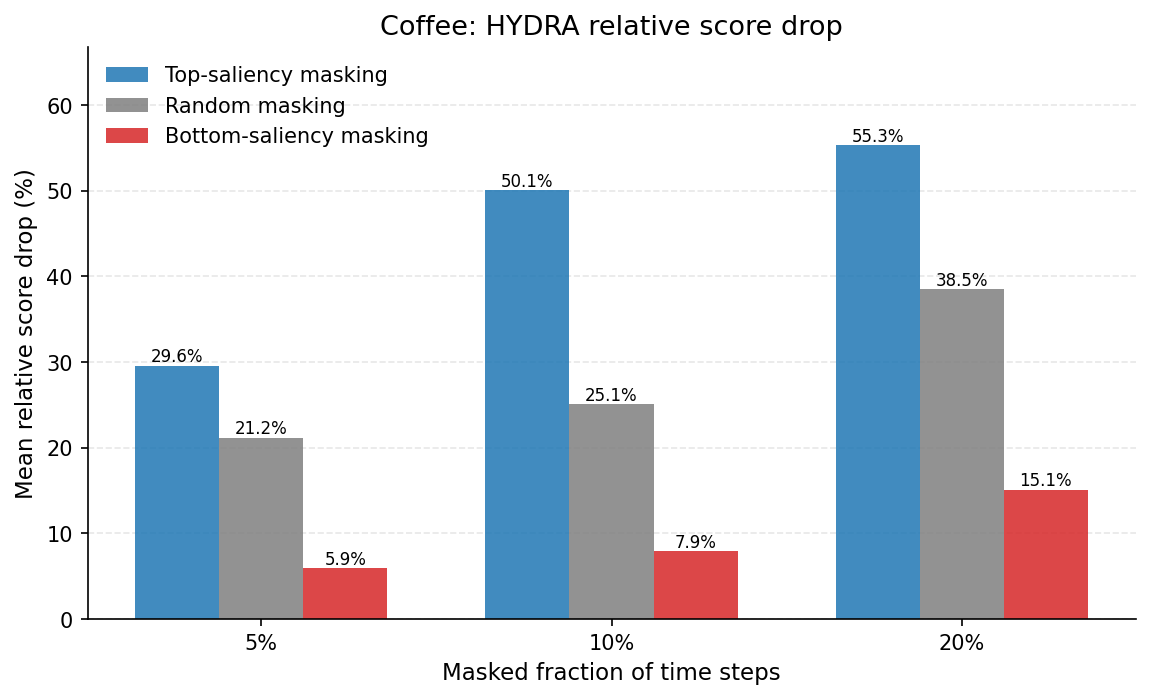

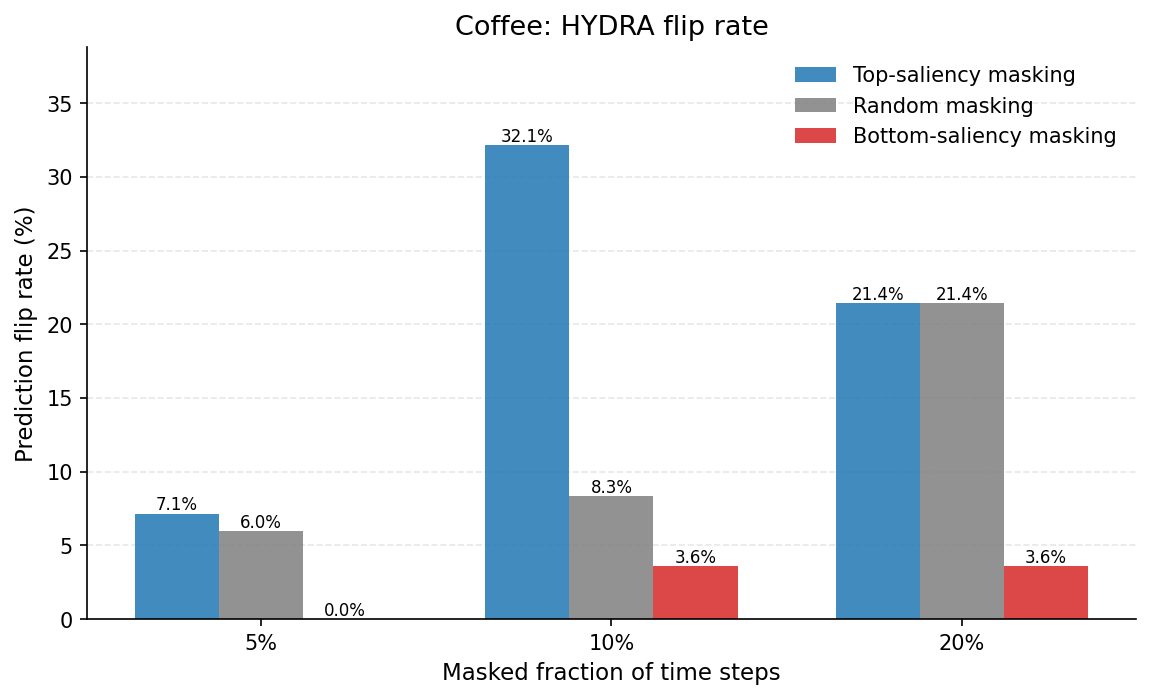

In [6]:
plot_grouped_bars(
    df=hydra_summary,
    value_col="mean_relative_score_drop_pct",
    title="Coffee: HYDRA relative score drop",
    ylabel="Mean relative score drop (%)",
    filename="hydra_mean_relative_score_drop_grouped_bars",
    show_percent_symbol=True,
)

plot_grouped_bars(
    df=hydra_summary,
    value_col="flip_rate_pct",
    title="Coffee: HYDRA flip rate",
    ylabel="Prediction flip rate (%)",
    filename="hydra_mean_flip_rate_grouped_bars",
    show_percent_symbol=True,
)


### HYDRA saliency example

The next cell visualises the saliency profile for one correctly classified Coffee test series.  Darker points indicate lower saliency and lighter points indicate higher saliency after normalisation to `[0, 100]`.


Example index    : 0
True label       : 0
HYDRA prediction : 0


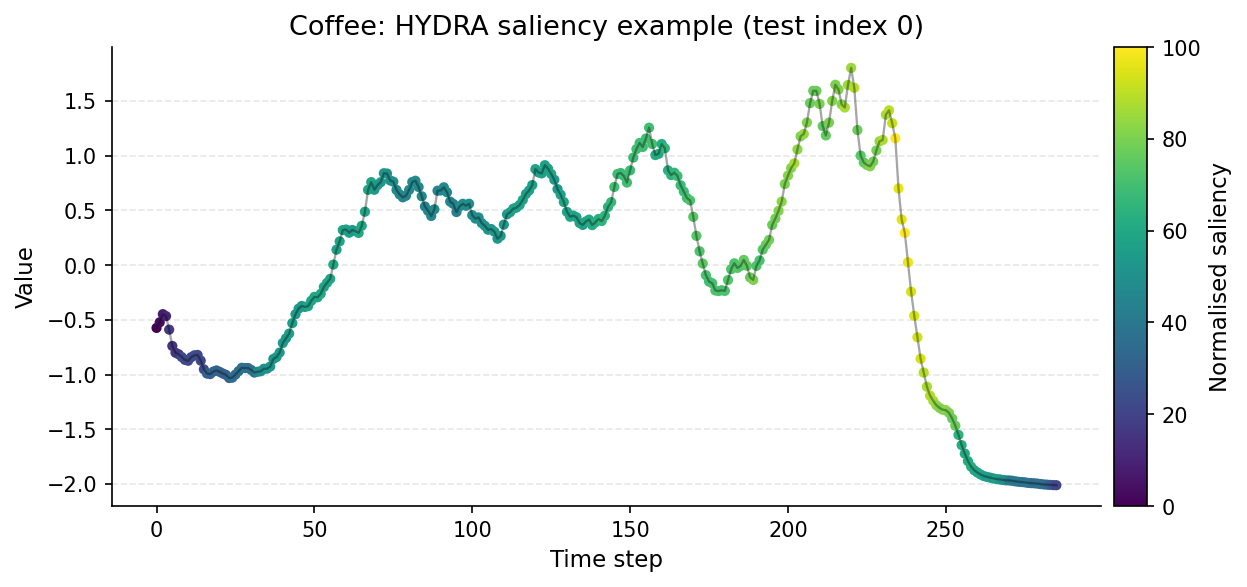

In [ ]:
correct_indices = np.where(hydra_preds == y_test)[0]
if len(correct_indices) == 0:
    raise ValueError("HYDRA did not correctly classify any Coffee test instances.")

example_idx = int(correct_indices[0])
example_series = x_test[example_idx]
example_label = y_test[example_idx]
example_pred = hydra_preds[example_idx]
example_saliency = hydra.explain(example_series)

print(f"Example index : {example_idx}")
print(f"True label : {example_label}")
print(f"HYDRA prediction : {example_pred}")

plot_signal_with_saliency(
    example_series,
    example_saliency,
    title=f"Coffee: HYDRA saliency example (test index {example_idx})",
    save_name="coffee_hydra_saliency_example",
)


## Fit MrSQM for comparison

MrSQM provides a useful comparator because it is an interpretability-oriented symbolic method with native temporal saliency support.  The same masking protocol is applied so that HYDRA and MrSQM are compared under a shared perturbation evaluation.


In [8]:
mrsqm = MrSQMExplainableModel(nsax=5, nsfa=0)
mrsqm.fit(x_train, y_train)

mrsqm_preds = mrsqm.predict(x_test)
mrsqm_acc = float(np.mean(mrsqm_preds == y_test))
print(f"MrSQM test accuracy on Coffee: {mrsqm_acc:.3f}")

mrsqm_samples, _ = evaluate_masking_dataset(
    model=mrsqm,
    X_test=x_test,
    y_test=y_test,
    fractions=FRACTIONS,
    use_absolute=True,
    only_correct=True,
    random_repeats=RANDOM_REPEATS,
    seed=SEED,
)

mrsqm_samples["dataset"] = DATASET
mrsqm_samples["model"] = "MrSQM"
mrsqm_summary = summarise_masking_metrics(mrsqm_samples)

display(mrsqm_summary)

mrsqm_samples.to_csv(OUTPUT_DIR / "coffee_mrsqm_samples.csv", index=False)
mrsqm_summary.to_csv(OUTPUT_DIR / "coffee_mrsqm_summary.csv", index=False)
print("Saved MrSQM masking results.")


MrSQM test accuracy on Coffee: 0.964
  processed 10/27 samples
  processed 20/27 samples


,fraction,mode,mean_relative_score_drop_pct,median_relative_score_drop_pct,mean_bounded_relative_score_drop,flip_rate,flip_rate_pct,n_samples
0,0.05,bottom,1.359851,1.217334,0.013599,0.000000,0.000000,27
1,0.05,random,31.637675,28.284736,0.303386,0.074074,7.407407,27
2,0.05,top,61.469305,47.987695,0.546333,0.074074,7.407407,27
3,0.10,bottom,5.676299,5.775000,0.056763,0.000000,0.000000,27
4,0.10,random,39.985904,39.723344,0.399859,0.012346,1.234568,27
5,0.10,top,68.216405,56.114620,0.632050,0.074074,7.407407,27
6,0.20,bottom,8.466762,8.680708,0.084668,0.000000,0.000000,27
7,0.20,random,53.127640,54.598884,0.531276,0.012346,1.234568,27
8,0.20,top,78.428155,75.804880,0.755060,0.074074,7.407407,27


Saved MrSQM masking results.


## 7. Compare HYDRA and MrSQM perturbation behaviour

The table below focuses on the 10% masking setting used for the main report tables.  The complete curves are plotted afterwards.


In [9]:
comparison = pd.concat(
    [hydra_summary.assign(model="HYDRA"), mrsqm_summary.assign(model="MrSQM")],
    ignore_index=True,
)

summary_10 = comparison[comparison["fraction"] == 0.10].sort_values(["model", "mode"])
print("Results at 10% masking")
display(summary_10)

score_drop_10 = (
    summary_10.pivot(index="model", columns="mode", values="mean_bounded_relative_score_drop")
    .reindex(columns=MODE_ORDER)
    .round(3)
)
print("Mean bounded relative score drop at 10% masking")
display(score_drop_10)

flip_rate_10 = (
    summary_10.pivot(index="model", columns="mode", values="flip_rate_pct")
    .reindex(columns=MODE_ORDER)
    .round(2)
)
print("Prediction flip rate (%) at 10% masking")
display(flip_rate_10)


Results at 10% masking


,fraction,mode,mean_relative_score_drop_pct,median_relative_score_drop_pct,mean_bounded_relative_score_drop,flip_rate,flip_rate_pct,n_samples,model
3,0.1,bottom,7.943066,20.098686,0.072554,0.035714,3.571429,28,HYDRA
4,0.1,random,25.061985,25.097894,0.208684,0.083333,8.333333,28,HYDRA
5,0.1,top,50.067765,87.184708,0.413135,0.321429,32.142857,28,HYDRA
12,0.1,bottom,5.676299,5.775000,0.056763,0.000000,0.000000,27,MrSQM
13,0.1,random,39.985904,39.723344,0.399859,0.012346,1.234568,27,MrSQM
14,0.1,top,68.216405,56.114620,0.632050,0.074074,7.407407,27,MrSQM


Mean bounded relative score drop at 10% masking


mode,top,random,bottom
model,,,
HYDRA,0.413,0.209,0.073
MrSQM,0.632,0.400,0.057


Prediction flip rate (%) at 10% masking


mode,top,random,bottom
model,,,
HYDRA,32.14,8.33,3.57
MrSQM,7.41,1.23,0.00


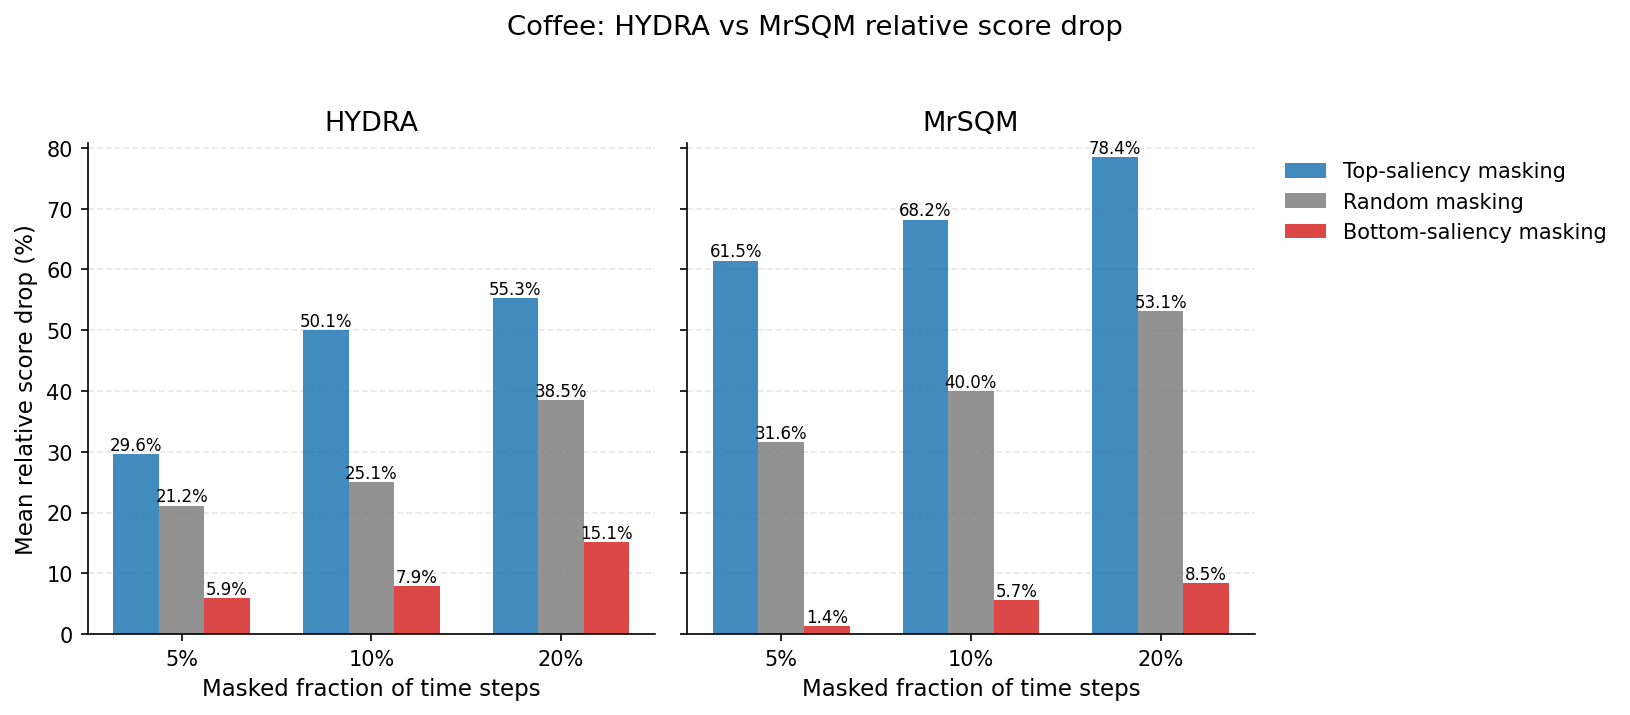

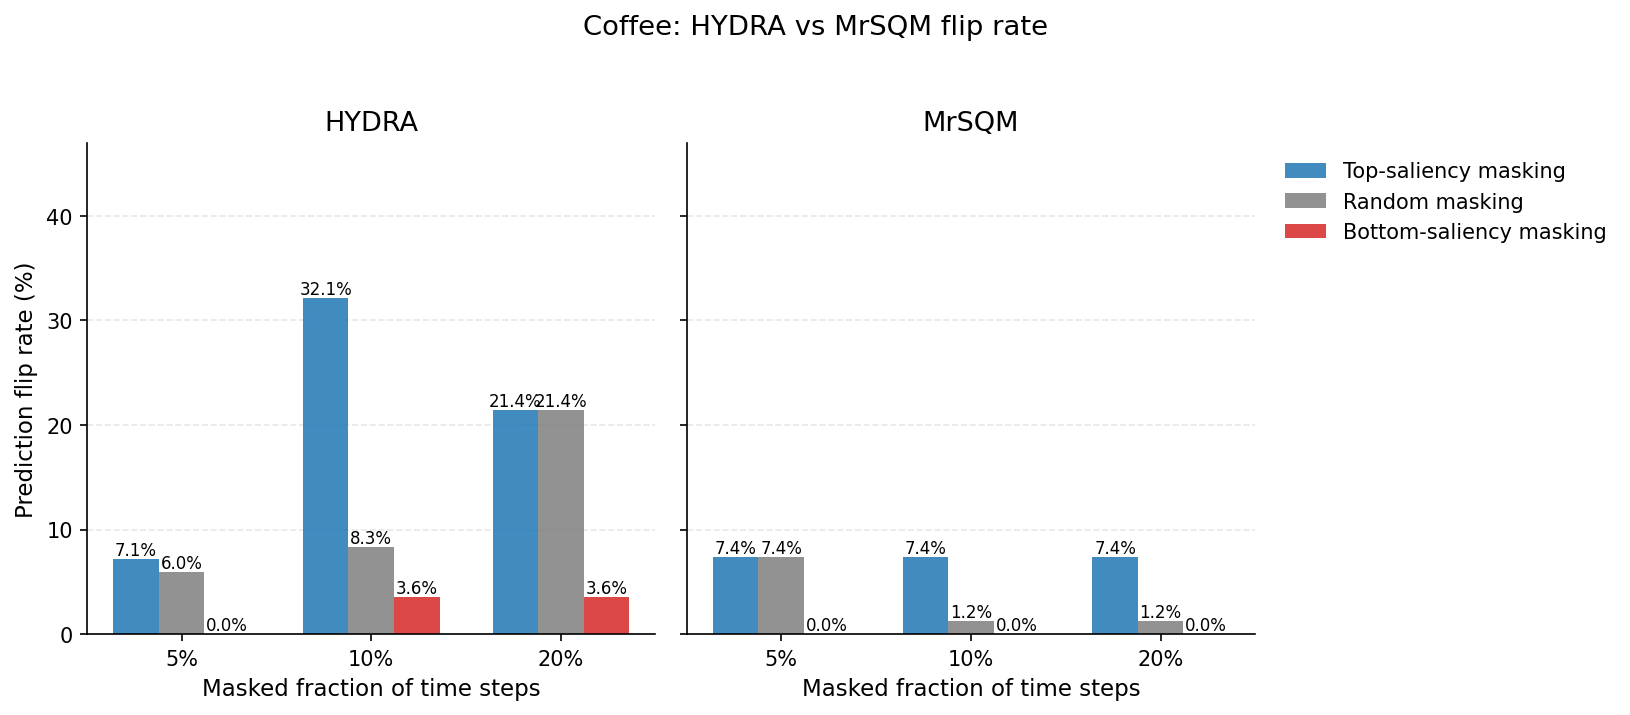

In [10]:
def plot_grouped_bars_by_model(
    df: pd.DataFrame,
    value_col: str,
    ylabel: str,
    title: str,
    filename: str,
    show_percent_symbol: bool = False,
) -> None:
    '''Plot one set of grouped bars per model'''
    models = ["HYDRA", "MrSQM"]
    fractions = sorted(df["fraction"].unique())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
    x = np.arange(len(fractions))
    width = 0.24
    offsets = [-width, 0, width]

    for ax, model_name in zip(axes, models):
        model_df = df[df["model"] == model_name]
        for offset, mode in zip(offsets, MODE_ORDER):
            sub = model_df[model_df["mode"] == mode].sort_values("fraction")
            y = sub[value_col].to_numpy()
            bars = ax.bar(
                x + offset,
                y,
                width=width,
                color=MODE_COLOURS[mode],
                alpha=0.85,
                label=MODE_LABELS[mode],
            )
            for bar, val in zip(bars, y):
                label = f"{val:.1f}%" if show_percent_symbol else f"{val:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=8)

        ax.set_title(model_name)
        ax.set_xlabel("Masked fraction of time steps")
        ax.set_xticks(x)
        ax.set_xticklabels([f"{f:.0%}" for f in fractions])
        style_axis(ax)
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(ymin, ymax * 1.18)

    axes[0].set_ylabel(ylabel)
    axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.suptitle(title, y=1.03)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


plot_grouped_bars_by_model(
    df=comparison,
    value_col="mean_relative_score_drop_pct",
    ylabel="Mean relative score drop (%)",
    title="Coffee: HYDRA vs MrSQM relative score drop",
    filename="coffee_hydra_vs_mrsqm_relative_score_drop",
    show_percent_symbol=True,
)

plot_grouped_bars_by_model(
    df=comparison,
    value_col="flip_rate_pct",
    ylabel="Prediction flip rate (%)",
    title="Coffee: HYDRA vs MrSQM flip rate",
    filename="coffee_hydra_vs_mrsqm_flip_rate",
    show_percent_symbol=True,
)


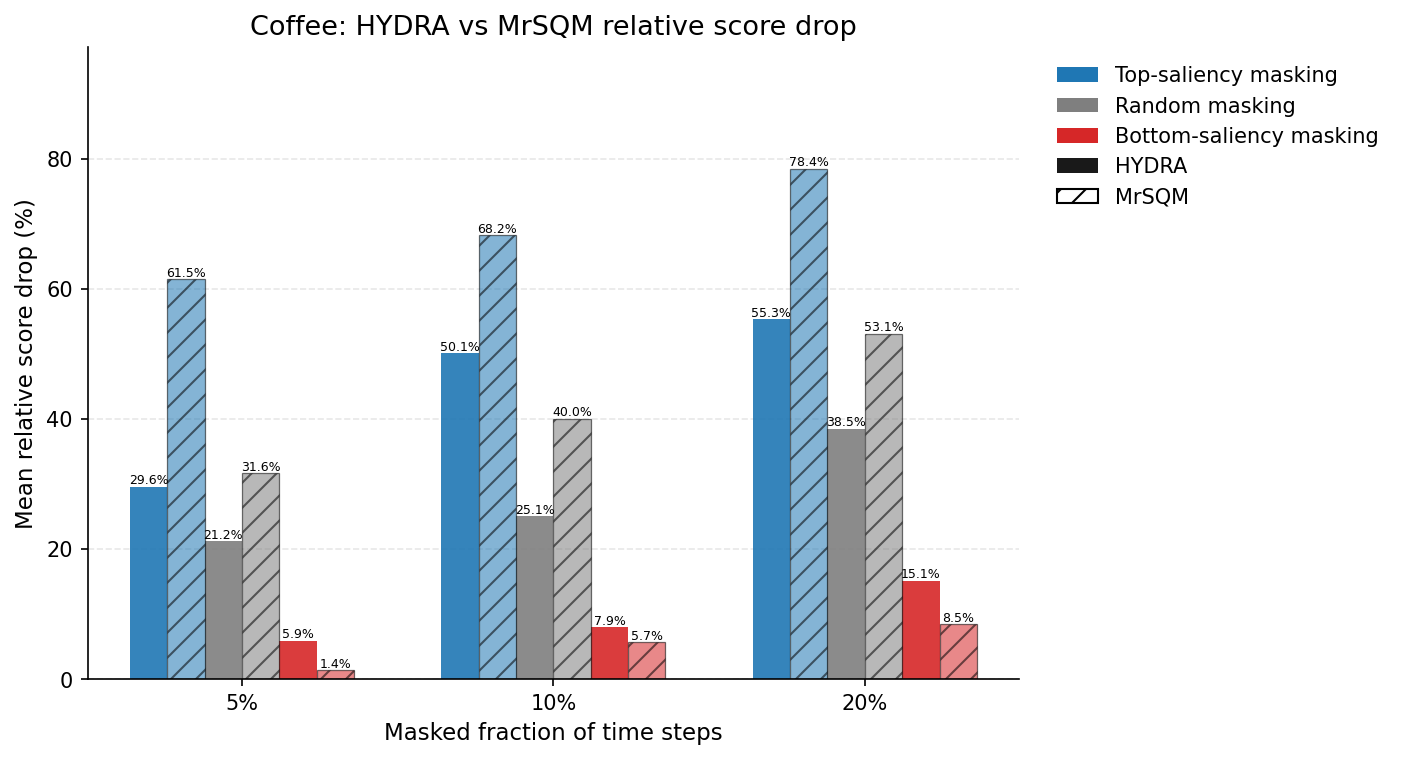

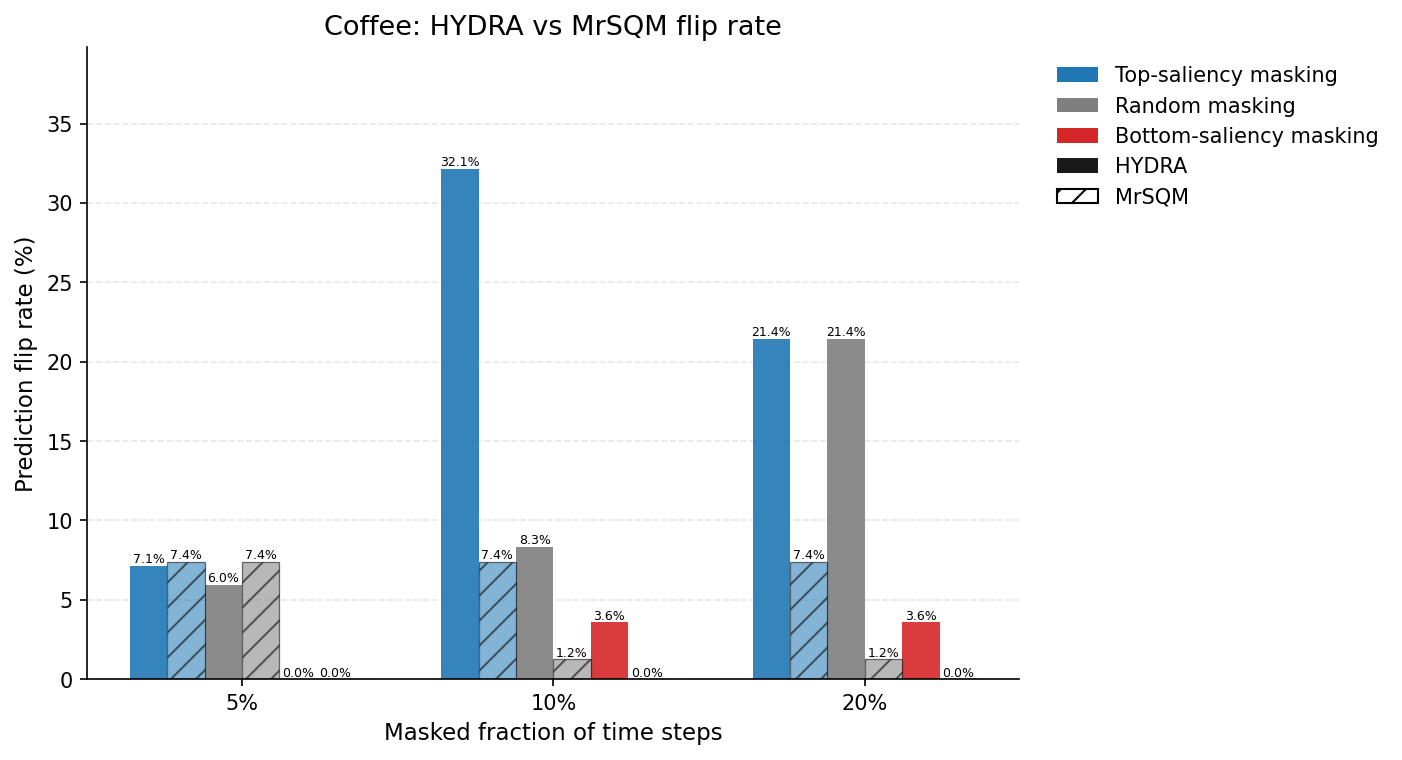

In [11]:
def plot_combined_model_bars(
    df: pd.DataFrame,
    value_col: str,
    ylabel: str,
    title: str,
    filename: str,
    show_percent_symbol: bool = False,
) -> None:
    '''Plot HYDRA and MrSQM side by side for each masking mode and fraction'''
    models = ["HYDRA", "MrSQM"]
    fractions = sorted(df["fraction"].unique())
    x = np.arange(len(fractions))
    width = 0.12
    offsets = {
        ("HYDRA", "top"): -2.5 * width,
        ("MrSQM", "top"): -1.5 * width,
        ("HYDRA", "random"): -0.5 * width,
        ("MrSQM", "random"): 0.5 * width,
        ("HYDRA", "bottom"): 1.5 * width,
        ("MrSQM", "bottom"): 2.5 * width,
    }

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    for model_name in models:
        for mode in MODE_ORDER:
            sub = df[(df["model"] == model_name) & (df["mode"] == mode)].sort_values("fraction")
            y = sub[value_col].to_numpy()
            bars = ax.bar(
                x + offsets[(model_name, mode)],
                y,
                width=width,
                color=MODE_COLOURS[mode],
                alpha=0.9 if model_name == "HYDRA" else 0.55,
                hatch=None if model_name == "HYDRA" else "//",
                edgecolor="black" if model_name == "MrSQM" else None,
                linewidth=0.6 if model_name == "MrSQM" else 0,
            )
            for bar, val in zip(bars, y):
                label = f"{val:.1f}%" if show_percent_symbol else f"{val:.2f}"
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha="center", va="bottom", fontsize=6)

    ax.set_title(title)
    ax.set_xlabel("Masked fraction of time steps")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{f:.0%}" for f in fractions])
    style_axis(ax)

    legend_handles = [
        Patch(facecolor=MODE_COLOURS["top"], label="Top-saliency masking"),
        Patch(facecolor=MODE_COLOURS["random"], label="Random masking"),
        Patch(facecolor=MODE_COLOURS["bottom"], label="Bottom-saliency masking"),
        Patch(facecolor="black", alpha=0.9, label="HYDRA"),
        Patch(facecolor="white", edgecolor="black", hatch="//", label="MrSQM"),
    ]
    ax.legend(handles=legend_handles, frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.18)
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


plot_combined_model_bars(
    df=comparison,
    value_col="mean_relative_score_drop_pct",
    ylabel="Mean relative score drop (%)",
    title="Coffee: HYDRA vs MrSQM relative score drop",
    filename="coffee_hydra_vs_mrsqm_relative_score_drop_combined",
    show_percent_symbol=True,
)

plot_combined_model_bars(
    df=comparison,
    value_col="flip_rate_pct",
    ylabel="Prediction flip rate (%)",
    title="Coffee: HYDRA vs MrSQM flip rate",
    filename="coffee_hydra_vs_mrsqm_flip_rate_combined",
    show_percent_symbol=True,
)


## Compare saliency maps on the same test series

The following figure compares the normalised saliency maps produced by HYDRA and MrSQM for a single test instance that both models classify correctly.  This is qualitative: the goal is to inspect whether the methods emphasise related temporal regions, not to treat either saliency map as ground truth.


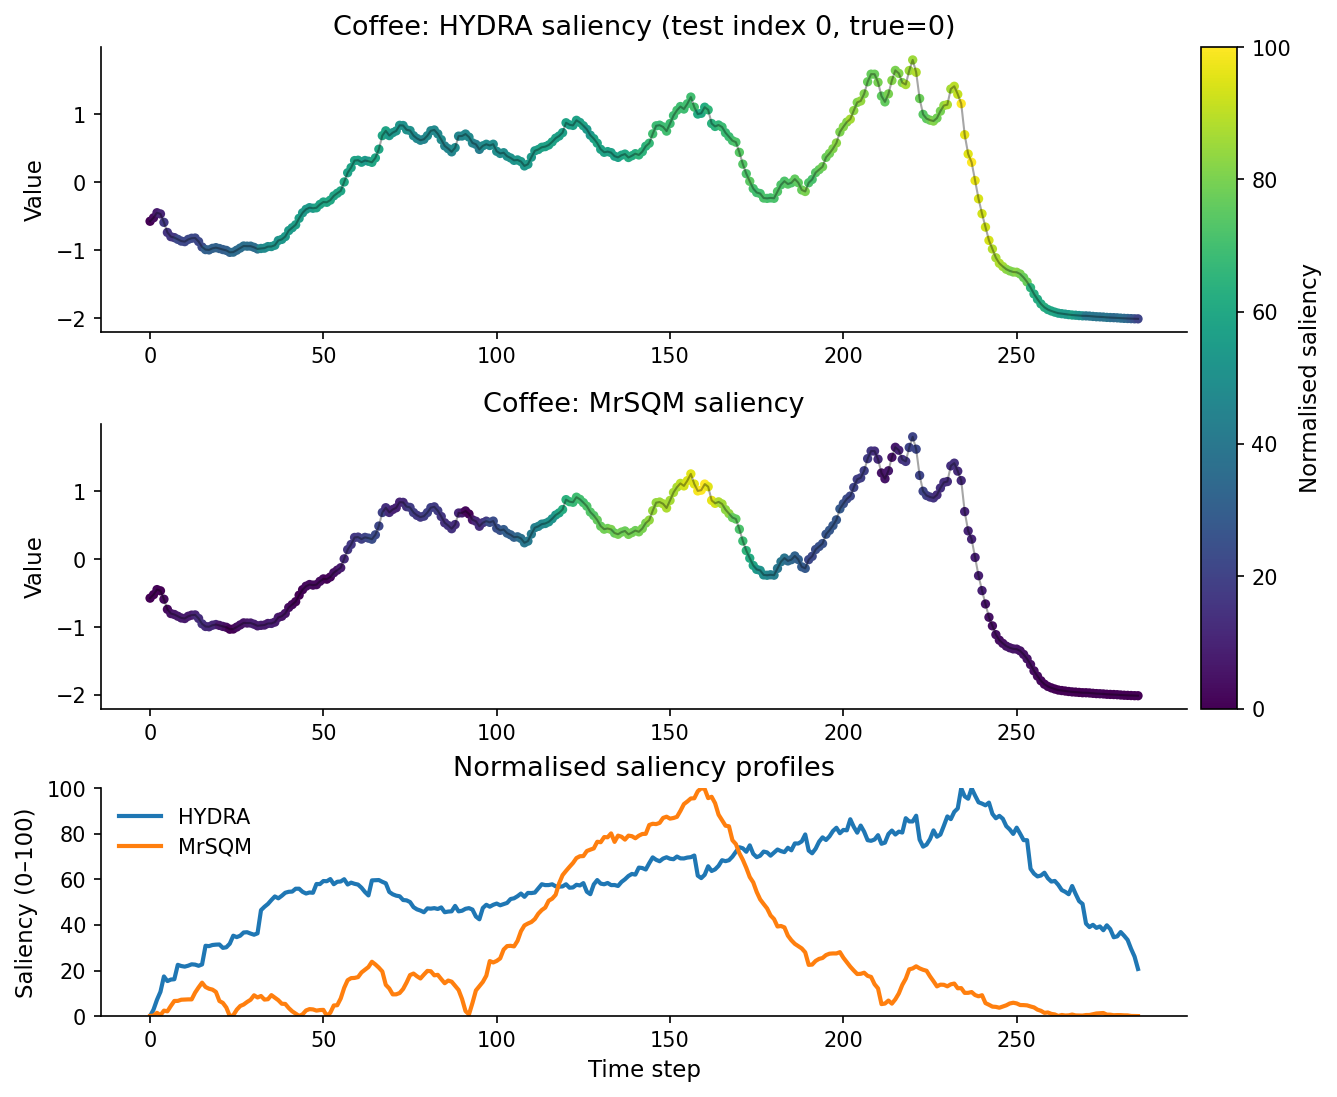

In [12]:
shared_idx = choose_shared_correct_example(hydra, mrsqm, x_test, y_test)
shared_series = x_test[shared_idx]
shared_true = y_test[shared_idx]

hydra_saliency = hydra.explain(shared_series)
mrsqm_saliency = mrsqm.explain(shared_series)

x = np.arange(len(as_1d(shared_series)))
y = as_1d(shared_series)
hydra_norm = normalise_0_100(hydra_saliency)
mrsqm_norm = normalise_0_100(mrsqm_saliency)

fig = plt.figure(figsize=(8.8, 7.2), constrained_layout=True)
gs = fig.add_gridspec(3, 2, width_ratios=[30, 1], height_ratios=[1, 1, 0.8])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)
cax = fig.add_subplot(gs[0:2, 1])

sc1 = ax1.scatter(x, y, c=hydra_norm, cmap="viridis", s=20, linewidths=0, vmin=0, vmax=100)
ax1.plot(x, y, color="black", alpha=0.35, linewidth=1)
ax1.set_title(f"Coffee: HYDRA saliency (test index {shared_idx}, true={shared_true})")
ax1.set_ylabel("Value")

sc2 = ax2.scatter(x, y, c=mrsqm_norm, cmap="viridis", s=20, linewidths=0, vmin=0, vmax=100)
ax2.plot(x, y, color="black", alpha=0.35, linewidth=1)
ax2.set_title("Coffee: MrSQM saliency")
ax2.set_ylabel("Value")

cbar = fig.colorbar(sc2, cax=cax)
cbar.set_label("Normalised saliency")

ax3.plot(x, hydra_norm, linewidth=2, label="HYDRA")
ax3.plot(x, mrsqm_norm, linewidth=2, label="MrSQM")
ax3.set_title("Normalised saliency profiles")
ax3.set_xlabel("Time step")
ax3.set_ylabel("Saliency (0–100)")
ax3.set_ylim(0, 100)
ax3.legend(frameon=False)

for ax in (ax1, ax2, ax3):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.savefig(FIG_DIR / "coffee_hydra_vs_mrsqm_saliency.png", dpi=300, bbox_inches="tight")
plt.show()
